<img src="https://userweb.fct.unl.pt/~jmc.xavier/MAI/iLogos/logo_novafct.png" width="200">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica Aplicada I 

## ANÁLISE DE VIGAS

### Problema 5 <a name="PV"></a>

A figura representa duas vigas ABC e CD, ligadas entre si por uma articulação em C. A viga ABC está encastrada em A e a viga CD tem um apoio móvel em D. Para os carregamentos representados na figura, determine:

[a)](#A) As reações nos apoios A e D.

[b)](#B) As equações do esforço transverso e do momento fletor para o troço CD.

[c)](#C) Os diagramas dos esforços internos para as duas vigas.

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P5/MAI_Ch08_P5.jpg"
width="800">


In [13]:
# unit: kN, kN.m, m
F, M = 10., 15.
LAB, LB2, L2C = 3., 2., 3.
LBC = LB2 + L2C

#### Resumo

**Determinação de Esforços em vigas**

Metodologia:

- Diagrama de corpo livre;
- Determinar reações nos apoios;
- Determinar os esforços internos (esforço transverso e momento flector);
- Desenhar os diagramas de esforço transverso e momento flector.

Programas de análise estrutural:

- [Ftool](https://www.ftool.com.br/Ftool/)
- [ANSYS Student](https://www.ansys.com/academic/free-student-products)
- [Robot Structural Analysis Professional](https://www.autodesk.com/education/free-software/featured)

### Resolução

#### a) As reações nos apoios A e D. <a id="A"></a> ([_enunciatum_](#PV))

**Sistema força e binário equivalente**

Inicia-se esta resolução identificando o sistema força e binário equivalenteconforme se ilustra pela figura abaixo:

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P5/MAI_Ch08_P5_a0.jpg"
width="800">

O DCL da viga fica assim definido de acordo com a figura abaixo:

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P5/MAI_Ch08_P5_a1.jpg"
width="800">

\begin{equation*}
\begin{aligned}
F_B &= F = 10~\textrm{kN} \\
M_B &= M + F\cdot 2 = 35~\textrm{kN.m} \\
\end{aligned}
\end{equation*}

In [14]:
FB = F
print(f'F  = {FB:.1f} kN')
MB = M + F*LB2
print(f'MB = {MB:.1f} kN.m')

F  = 10.0 kN
MB = 35.0 kN.m


Do DCL da viga podem-se identificar 4 reações (4 incógnitas) pelo que, será necessário adicionar mais uma equação de equilíbrio estático independente (definida mais adiante) às 3 equações de equilíbrio estático da viga.

**Cálculo das reações**

##### Força distribuida triangular

Antes de calcular as reações na viga, calculam-se a força equivalente $P_{eq}$ e a sua posição $\overline{X}$ na viga conforme se mostra na figura abaixo.

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P5/MAI_Ch08_P5_a2.jpg"
width="800">

Considere-se um eixo coordenado com origem no ponto C. Desta forma, têm-se:

\begin{equation*}
\begin{aligned}
P_{eq} &= \frac{QL_\textrm{CD}}{2} = 120~\textrm{kN} \\
\overline{x} &= \frac{2}{3}L_\textrm{CD} = 5.3 ~\textrm{m} \\
\end{aligned}
\end{equation*}

In [15]:
LCD, QD = 8., 30. # m, kN

xcent = 2/3*LCD
print('xcent.CD = ','{:.1f}'.format(xcent),' m')

Peq = QD*LCD/2
print('Peq.CD = ','{:.1f}'.format(Peq),' kN')

xcent.CD =  5.3  m
Peq.CD =  120.0  kN


Por conveniência pode-se separar a viga em dois troços ABC e no troço CD, estudando o equilíbrio individual de cada parte para a determinação das reações.

**Equilíbrio da parta CD da viga**

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P5/MAI_Ch08_P5_a3.jpg"
width="800">

As equações de equilíbrio estático permitem escrever:

\begin{equation*}
\begin{cases}
\rightarrow(+)&:& \sum F_x = 0 \\
\uparrow(+) &:&\sum F_y = 0 \\
\circlearrowleft(+)&:&\sum M_C = 0
\end{cases}~\Leftrightarrow~
\begin{cases}
R_{Cx} = 0\\
R_{Cy} + R_{Dy} - P_{eq} = 0\\
- P_{eq}\cdot\displaystyle\frac{2}{3}L_{CD} + R_{Dy}\cdot L_{CD} = 0
\end{cases}
~\Leftrightarrow~
\begin{cases}
R_{Cx} = 0~\textrm{kN}\\
R_{Cy} = 40~\textrm{kN}\\
R_{Dy} = 80~\textrm{kN.m}
\end{cases}
\end{equation*}

In [16]:
import sympy as sy
from sympy.solvers import solve

rcx, rcy, rdy = sy.symbols('rcx rcy rdy')

# sumFx = ax - f
sumFx = rcx
print('\nSum Fx :',sumFx)
# sumFy = ay - qb*lab/2 - qb*lbc/2 - m*g
sumFy = rcy + rdy - Peq
print('Sum Fy :',sumFy)
# sumMA = ma - qb*lab/2*(lab - lab/3) - qb*lab/2*(lab + lbc/3) - f*lbd - m*g*lab
sumMA = - Peq*2/3*LCD + rdy*LCD
print('Sum sumMA :',sumMA)
sol = solve({sumFx,sumFy, sumMA},{rcx, rcy, rdy})

RCx = sol[rcx]
print('\nRCx = ','{:.1f}'.format(RCx),' kN')
RCy = sol[rcy]
print('RCy = ','{:.1f}'.format(RCy),' kN')
RDy = sol[rdy]
print('RDy = ','{:.1f}'.format(RDy),' kN')


Sum Fx : rcx
Sum Fy : rcy + rdy - 120.0
Sum sumMA : 8.0*rdy - 640.0

RCx =  0.0  kN
RCy =  40.0  kN
RDy =  80.0  kN


**Equilíbrio da parta ABC da viga**

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P5/MAI_Ch08_P5a.jpg"
width="800">

\begin{equation*}
\begin{cases}
\sum F_x = 0 \\
\sum F_y = 0 \\
\sum M_A = 0
\end{cases}~\Leftrightarrow~
\begin{cases}
-R_{Cx} + R_{Ax} = 0\\
-R_{Cy} + R_{Ay} - F_B = 0\\
M_A - M_B - 3F_B - 8 R_{Cy}= 0
\end{cases}
~\Leftrightarrow~
\begin{cases}
R_{Ax} = 0~\textrm{kN}\\
R_{Ay} = 50~\textrm{kN}\\
M_A = 385~\textrm{kN.m}
\end{cases}
\end{equation*}

In [17]:
rax, ray, ma = sy.symbols('rax, ray, ma')

# sumFx = ax - f
sumFx = -RCx + rax
print('\nSum Fx :',sumFx)
# sumFy = ay - qb*lab/2 - qb*lbc/2 - m*g
sumFy = -RCy + ray - FB
print('Sum Fy :',sumFy)
# sumMA = ma - qb*lab/2*(lab - lab/3) - qb*lab/2*(lab + lbc/3) - f*lbd - m*g*lab
sumMA = ma - MB - LAB*FB - (LAB+LBC)*RCy
print('Sum sumMA :',sumMA)
sol = solve({sumFx,sumFy, sumMA},{rax, ray, ma})

RAx = sol[rax]
print('\nRAx = ','{:.1f}'.format(RAx),' kN')
RAy = sol[ray]
print('RAy = ','{:.1f}'.format(RAy),' kN')
MA = sol[ma]
print('MA = ','{:.1f}'.format(MA),' kN.m')


Sum Fx : rax
Sum Fy : ray - 50.0
Sum sumMA : ma - 385.0

RAx =  0.0  kN
RAy =  50.0  kN
MA =  385.0  kN.m


#### b) As equações do esforço transverso e do momento fletor para o troço CD.  <a id="B"></a> ([_enunciatum_](#PV))

**Métodologia**

Procede-se ao cálculo dos esforços internos: o esforço transverso e do momento fletor para a viga AC. Para isso, dever-se-ão considerar três troços na viga: (i) troço AB; (ii) troço BC; e (iii) troço CD.

**(i) Troço AB - $x \in [0; 3[$ [m]**

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P5/MAI_Ch08_P5_a4.jpg"
width="800">

Equações equilíbrio:

\begin{equation*}
\begin{cases}
\sum F_y = 0 \\
\sum M_{B'} = 0
\end{cases}~\Leftrightarrow~
\begin{cases}
R_{Ay} - V(x) = 0\\
M(x) + M_A - R_{Ay} \cdot x = 0\\
\end{cases}
~\Leftrightarrow~
\begin{cases}
V(x) = 50~\textrm{kN}\\
M(x) = 50x - 385 ~\textrm{kN.m}
\end{cases}
\end{equation*}

In [18]:
vab, mab, x = sy.symbols('vab mab x')

EqET = RAy - vab
EqMF = mab + MA - RAy*x

sol = solve({EqET,EqMF},{vab, mab})

print('Troço AB:')
print('Esforço Transverso, V(x):')
VAB = sol[vab]
print('V(x) = ',VAB,' kN')
print('Momento fletor, M(x):')
MAB = sol[mab]
print('M(x) = ',MAB,' kN.m')

Troço AB:
Esforço Transverso, V(x):
V(x) =  50.0000000000000  kN
Momento fletor, M(x):
M(x) =  50.0*x - 385.0  kN.m


**(ii) Troço BC - $x \in [3; 8[$ [m]**

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P5/MAI_Ch08_P5_a5.jpg"
width="800">

Equações equilíbrio:

\begin{equation*}
\begin{cases}
\sum F_y = 0 \\
\sum M_{C'} = 0
\end{cases}~\Leftrightarrow~
\begin{cases}
R_{Ay} - F_B - V(x) = 0\\
M(x) + M_A - M_B - R_{Ay} \cdot x
+ F_B \cdot (x-3) = 0\\
\end{cases}
~\Leftrightarrow~
\begin{cases}
V(x) = 40~\textrm{kN}\\
M(x) = 40x - 320 ~\textrm{kN.m}
\end{cases}
\end{equation*}

In [19]:
vbc, mbc = sy.symbols('vbc mbc')

EqET = RAy - FB - vbc
EqMF = mbc + MA - MB - RAy*x + FB*(x-LAB)

sol = solve({EqET,EqMF},{vbc, mbc})

print('Troço BC:')
print('Esforço Transverso, V(x):')
VBC = sol[vbc]
print('V(x) = ',VBC,' kN')
print('Momento fletor, M(x):')
MBC = sol[mbc]
print('M(x) = ',MBC,' kN.m')

Troço BC:
Esforço Transverso, V(x):
V(x) =  40.0000000000000  kN
Momento fletor, M(x):
M(x) =  40.0*x - 320.0  kN.m


Pode-se avaliar o momento fletor nos extremos do intervalo quando $x =
3$ m e $x = 8$ m:

\begin{equation*}
M(x=3) = -200\quad \textrm{kN.m}
\quad\wedge\quad
M(x=8) = 0\quad \textrm{kN.m}
\end{equation*}

Note-se que para $x = 8$ m, seria expectável que o momento flector fosse nulo uma vez que no Ponto C (i.e. para $x = 8$ m)
existe uma rótula (ou articulação) que liberta a viga de momentos nesse ponto, ou seja, impõe momentos nulos em C conforme se pode verificar pela equação de equilíbrio atrás definidas.

**(iii) Troço CD - $x \in [0; 8[$ [m]**

Para simplificar o cálculo do troço CD, considera-se este troço isolado com um eixo coordenado com origem no ponto C. Por conseguinte, tem-se que $x \in [0; 8]$ m. Nestas circunstâncias, deve-se considerar o DCL ilustrado na figura abaixo onde as forças em C correspondem ao esforço normal (0 kN) e transverso (40kN) conforme determinados na alínea anterior pelas equações de equilíbrio.

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P5/MAI_Ch08_P5_a6.jpg"
width="800">

A carga linearmente distribuida ao longo da barra CD, $w(x)$, pode ser definida por uma função polinomial descrita pela equação genérica da reta:

\begin{equation*}
y - y_0 = m (x- x_0)~,\quad\textrm{com}\quad
m = \frac{y_1-y_0}{x_1-x_0}
\end{equation*}

Em que $P_0(x_0,y_0)$ e $P_1(x_1,y_1)$ são os pontos extremos do segmento de reta. Para um referencial orientado ao longo da barra AB e com origem em A, têm-se:

\begin{equation*}
\begin{aligned}
P_0(0,0)\quad\textrm{e}\quad P_1(L_{CD},Q_D)
\quad\therefore\quad
w(x) &= \frac{Q_D}{L_{CD}}x\\
~\Leftrightarrow~
w_1(x) &= \frac{30}{8}x = 3.75 \,x\quad\textrm{(kN)}
\end{aligned}
\end{equation*}

O equilíbrio estático permite escrever:

\begin{equation*}
\begin{cases}
W(x) - V(x) : \\
V(x) - M(x) :
\end{cases}~\Leftrightarrow~
\begin{cases}
V(x) = V_C - \displaystyle\int_0^x w(x) \mathrm{d}x \\
M(x) = M_C + \displaystyle\int_0^x V(x) \mathrm{d}x
\end{cases}
\end{equation*}

Desenvolvendo, o esforço de corte ou transverso vem:

\begin{equation*}
\begin{aligned}
V(x) &= V_C - \int_0^x w(x) \mathrm{d}x =
40 - \int_0^x 3.75 x \mathrm{d}x \\
&= 40 - 3.75\left[\frac{x^2}{2}\right]_0^x
= -1.875 x^2 + 40
\end{aligned}
\end{equation*}

In [20]:
print('\nVIGA CD:')
print('\nCarga distribuida, w(x):')
Vx0 = VBC.subs(x,0)
print('V(x=0).CD = ','{:.1f}'.format(Vx0),' kN')
wCD = QD/LCD*x
print('w(x).CD = ',wCD)
print('\nEsforço Transverso, V(x):')
# integrant function
iCD1 = sy.integrate(wCD, (x,0,x))
print('int w.CD = ',iCD1)
VCD = Vx0 - iCD1
print('V(x).CD  = ',VCD,' kN')

VCD0 = VCD.subs(x,0)
print('\nV(x=0).CD   = ','{:.1f}'.format(VCD0),' kN')
VCD1 = VCD.subs(x,LCD)
print('V(x=LCD).CD = ','{:.1f}'.format(VCD1),' kN')


VIGA CD:

Carga distribuida, w(x):
V(x=0).CD =  40.0  kN
w(x).CD =  3.75*x

Esforço Transverso, V(x):
int w.CD =  1.875*x**2
V(x).CD  =  40.0 - 1.875*x**2  kN

V(x=0).CD   =  40.0  kN
V(x=LCD).CD =  -80.0  kN


Por sua vez, o momento fletor vem:

\begin{equation*}
\begin{aligned}
M(x) &= M_C + \int_0^x V(x) \mathrm{d}x =
0 + \int_0^x (-1.875 x^2 + 40) \mathrm{d}x \\
&= \left[-1.875 \frac{x^3}{3} + 40\, x \right]_0^x
= -0.625\, x^3 + 40\,x
\end{aligned}
\end{equation*}

In [21]:
Mx0 = MBC.subs(x,LAB+LBC)
print('M(x=0).CD = ',Mx0,' kN.m')

print('\nMomento fletor, M(x):')
iBC2 = sy.integrate(VCD, (x,0,x))
print('int V(x).BC = ',iBC2)
MCD = Mx0 + iBC2
print('M(x).CD     = ',MCD,' kN.m')

MCD0 = MCD.subs(x,0)
print('\nM(x=0).CD   = ',MCD0,' kN')
MCD1 = MCD.subs(x,LCD)
print('M(x=LCD).CD = ',MCD1,' kN')

M(x=0).CD =  0  kN.m

Momento fletor, M(x):
int V(x).BC =  -0.625*x**3 + 40.0*x
M(x).CD     =  -0.625*x**3 + 40.0*x  kN.m

M(x=0).CD   =  0  kN
M(x=LCD).CD =  0  kN


#### c) Os diagramas dos esforços internos para as duas vigas. <a id="C"></a> ([_enunciatum_](#PV))

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P5/MAI_Ch08_P5_a7.jpg"
width="800">

--------------------------------
Troço CD: Momento fletor máximo
--------------------------------
VCD(x) = 0 >>> x (in CD) = 4.619 m | x (global) = 12.619 m
Mmax(x.V=0)  =  123.168  kN.m
max(Mplot)   =  123.168  kN.m (verification)


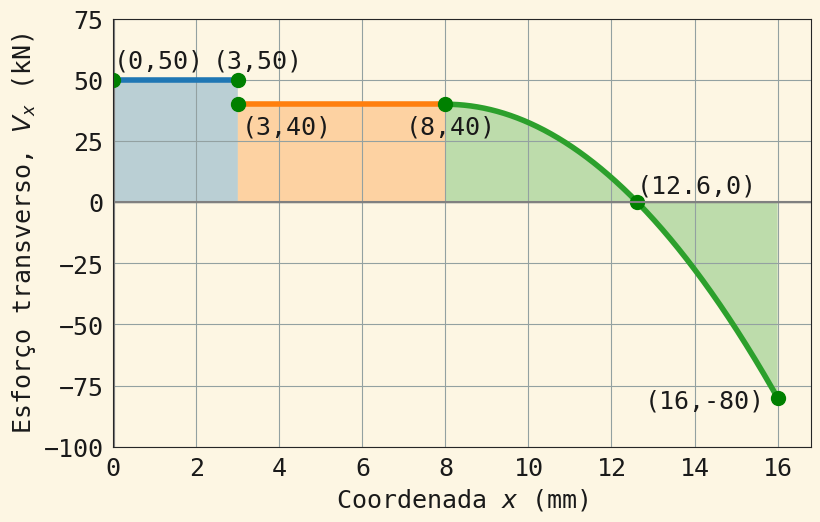

In [22]:
import numpy as np
import matplotlib.pyplot as plt

xAB = np.linspace(0,LAB,1000)
xBC = np.linspace(LAB,LAB+LBC,1000)
xCD = np.linspace(0,LCD,1000)

def sy2array(sygunc,xlist):
    scalar_func = lambda xx: float(sygunc.evalf(subs={x: xx}))
    vector_func = np.vectorize(scalar_func)
    return vector_func(xlist)

# AB
VABplot = sy2array(VAB,xAB) #
MABplot = sy2array(MAB,xAB) #

# BC
VBCplot = sy2array(VBC,xBC) #
MBCplot = sy2array(MBC,xBC) #

# CD
VCDplot = sy2array(VCD,xCD) #
MCDplot = sy2array(MCD,xCD) #

print('--------------------------------')
print('Troço CD: Momento fletor máximo')
print('--------------------------------')
sol1 = solve(VCD,x)
xVCD0l = sol1[1]
xVCD0g = LAB+LBC+sol1[1]
print(f'VCD(x) = 0 >>> x (in CD) = {xVCD0l:.3f} m | x (global) = {xVCD0g:.3f}'
      f' m')
Mmax = MCD.subs(x,xVCD0l)
print('Mmax(x.V=0)  = ','{:.3f}'.format(Mmax),' kN.m')
print('max(Mplot)   = ','{:.3f}'.format(np.max(MCDplot)),' kN.m (verification)')

# Define a switch for the color theme
use_light_theme = True

if use_light_theme:
    # Solarized Light Theme Colors
    background_color = (253/255, 246/255, 227/255)
    font_color = (0.1, 0.1, 0.1)
    grid_color = (147/255, 161/255, 161/255)
else:
    # Dark Theme Colors
    background_color = (.15, .15, .15)
    font_color = (.8, .8, .8)
    grid_color = (.2, .2, .2)

plt.rcParams['axes.facecolor'] = background_color
plt.rcParams['figure.facecolor'] = background_color
plt.rcParams['font.family'] = 'monospace'
plt.rcParams['font.size'] = 18
# plt.rcParams['text.usetex'] = True

params = {
    "ytick.color": font_color,
    "xtick.color": font_color,
    "grid.color": grid_color,
    "text.color": font_color,
    "axes.labelcolor": font_color,
    "axes.edgecolor": (.15, .15, .15)
}

plt.rcParams.update(params)

fig = plt.figure(figsize=(9,5.56))
ax = fig.add_subplot(1, 1, 1)
plt.axhline(linewidth=1,color=(.5, .5, .5))
plt.axvline(linewidth=3,color=(.5, .5, .5))
plt.plot(xAB,VABplot,linewidth=4)
plt.fill_between(xAB,VABplot, alpha=.3)
plt.plot(xBC,VBCplot,linewidth=4)
plt.fill_between(xBC,VBCplot, alpha=.3)
plt.plot(LAB+LBC+xCD,VCDplot,linewidth=4)
plt.fill_between(LAB+LBC+xCD,VCDplot, alpha=.3)
plt.xlabel('Coordenada $x$ (mm)')
plt.ylabel('Esforço transverso, $V_{x}$ (kN)')
plt.plot(xAB[0],VABplot[0],'go',markersize=10)
plt.text(xAB[0]+.01,VABplot[0]*1.1,f'({xAB[0]:.0f},{VABplot[0]:.0f})',
         fontsize=18)
plt.plot(xAB[-1],VABplot[-1],'go',markersize=10)
plt.text(xAB[-1]*.8,VABplot[-1]*1.1,f'({xAB[-1]:.0f},{VABplot[-1]:.0f})',
         fontsize=18)
plt.plot(xBC[0],VBCplot[0],'go',markersize=10)
plt.text(xBC[0]*1.03,VBCplot[0]*.7,f'({xBC[0]:.0f},{VBCplot[0]:.0f})',
         fontsize=18)
plt.text(xBC[-1]*.88,VBCplot[-1]*.7,f'({xBC[-1]:.0f},{VBCplot[-1]:.0f})',
         fontsize=18)
plt.plot(xBC[-1],VBCplot[-1],'go',markersize=10)
xf = LAB+LBC+xCD[-1]
plt.text(xf*.8,VCDplot[-1]*1.05,f'({xf:.0f},{VCDplot[-1]:.0f})',fontsize=18)
plt.plot(LAB+LBC+xCD[-1],VCDplot[-1],'go',markersize=10)
x0 = xVCD0g
y0 = VCD.subs(x,xVCD0l)
plt.text(x0*1.0,y0+4,f'({x0:.1f},{y0})',fontsize=18)
plt.plot(x0,y0,'go',markersize=10)
plt.axhline(y=0, color='gray', linestyle='-')
plt.axvline(x=0, color='gray', linestyle='-')
plt.xlim(0,(LAB+LBC+LCD)*1.05)
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')
# Customize minor tick labels
xrang = np.arange(0, 18, 2) # [0,2,4,6,8,10,12,14,16]
ax.set_xticks(xrang)
ax.set_xticklabels([i for i in xrang])
# ax.set_xticklabels(['0','2','4','6','8','10','12','14','16'])
plt.ylim(-100,75)
plt.grid(True)
plt.show()

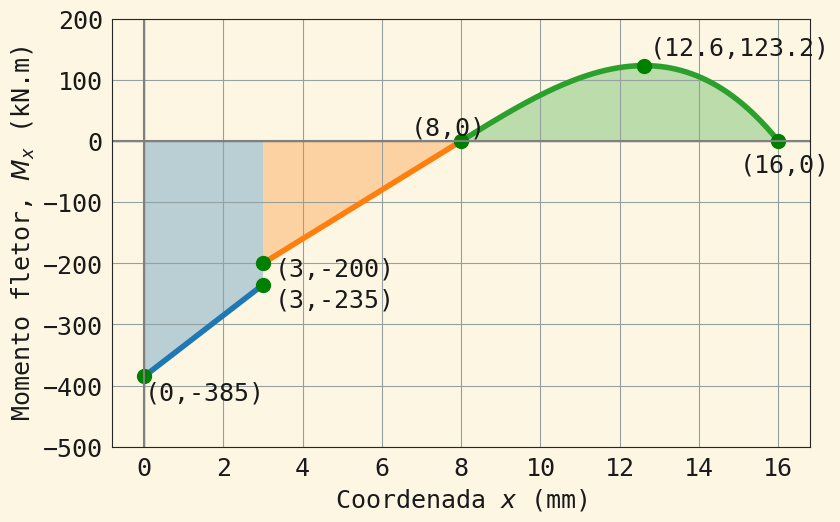

In [23]:
fig = plt.figure(figsize=(9,5.56))
ax = fig.add_subplot(1, 1, 1)
plt.axhline(linewidth=1,color=(.5, .5, .5))
plt.axvline(linewidth=1,color=(.5, .5, .5))
plt.plot(xAB,MABplot,linewidth=4)
plt.fill_between(xAB,MABplot, alpha=.3)
plt.plot(xBC,MBCplot,linewidth=4)
plt.fill_between(xBC,MBCplot, alpha=.3)
plt.plot(LAB+LBC+xCD,MCDplot,linewidth=4)
plt.fill_between(LAB+LBC+xCD,MCDplot, alpha=.3)
plt.xlabel(r'Coordenada $x$ (mm)')
plt.ylabel(r'Momento fletor, $M_{x}$ (kN.m)')
plt.plot(xAB[0],MABplot[0],'go',markersize=10)
plt.text(xAB[0]+.01,MABplot[0]*1.1,f'({xAB[0]:.0f},{MABplot[0]:.0f})',
         fontsize=18)
plt.plot(xAB[-1],MABplot[-1],'go',markersize=10)
plt.text(xAB[-1]*1.1,MABplot[-1]*1.15,f'({xAB[-1]:.0f},{MABplot[-1]:.0f})',
         fontsize=18)
plt.plot(xBC[0],MBCplot[0],'go',markersize=10)
plt.text(xBC[0]*1.1,MBCplot[0]*1.1,f'({xBC[0]:.0f},{MBCplot[0]:.0f})',
         fontsize=18)
plt.text(xBC[-1]*.84,MBCplot[-1]+10,f'({xBC[-1]:.0f},{MBCplot[-1]:.0f})',
         fontsize=18)
plt.plot(xBC[-1],MBCplot[-1],'go',markersize=10)
xf = LAB+LBC+xCD[-1]
plt.text(xf*.94,MCDplot[-1]-50,f'({xf:.0f},{MCDplot[-1]:.0f})',fontsize=18)
plt.plot(LAB+LBC+xCD[-1],MCDplot[-1],'go',markersize=10)
x0 = xVCD0g
y0 = MCD.subs(x,xVCD0l)
plt.text(x0*1.01,y0*1.15,f'({x0:.1f},{y0:.1f})',fontsize=18)
plt.plot(x0,y0,'go',markersize=10)
plt.axhline(y=0, color='gray', linestyle='-')
plt.axvline(x=0, color='gray', linestyle='-')
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')
ax.set_xticks(xrang)
ax.set_xticklabels([i for i in xrang])
plt.ylim(-500,200)
plt.grid(True)
plt.show()

---

Copyright (c) DEMI - FCT NOVA

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>